# Validación de la función de costo (con efecto real)

**Fase 4-5 · Tesis PR-196.** Aquí se ve la función de costo trabajando sobre una comparación **viva**: las políticas deciden, las acciones **re-entrenan el modelo de verdad**, y el costo (daño + acciones) mide quién decide mejor.

`costo = Σ(daño del mes) + Σ(costo de la acción)`, con el daño proporcional a la caída del AUC real.

## Preparación y carga

In [1]:
import os, sys
from pathlib import Path

raiz = Path.cwd()
while not (raiz / "src").exists():
    raiz = raiz.parent
os.chdir(raiz)
sys.path.insert(0, str(raiz / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from tesis.modelo_base import ModeloBase
from tesis.simulador.poblacion import cargar_poblacion, COHORTE_OOT
from tesis.simulador.simulador import ConfigSimulacion, plan_sano, agregar_episodio
from tesis.senales.monitor import Referencia
from tesis.politicas import crear, ClienteSimulado, PoliticaLLM
from tesis.experimentos.banco import comparar_con_efecto
from tesis.experimentos.costo import Costos, dano_mes

modelo = ModeloBase.cargar("models/modelo_base.pkl")
pool = cargar_poblacion(cohorte=COHORTE_OOT)
dev = cargar_poblacion(cohorte=None); dev = dev[dev["FECHA_CORTE"] < COHORTE_OOT]
referencia = Referencia.construir(dev, modelo)

def politicas():
    return {
        "reglas": crear("reglas"),
        "multisenal": crear("multisenal"),
        "llm(sim)": PoliticaLLM(cliente=ClienteSimulado()),   # simulado: gratis
    }
print("listo — pool:", pool.shape)

listo — pool: (9697, 2506)


## Chequeo 1 — la fórmula del daño

Un mes totalmente roto (AUC ≈ 0.5) vale 1.0; sano vale 0; peor que aleatorio se topa en el `cap`.

In [2]:
c = Costos()
pd.DataFrame({"AUC_real": [0.885, 0.83, 0.70, 0.50, 0.18],
             "dano_mes": [dano_mes(a, c) for a in [0.885, 0.83, 0.70, 0.50, 0.18]]})

,AUC_real,dano_mes
0,0.885,0.0000
1,0.830,0.1429
2,0.700,0.4805
3,0.500,1.0000
4,0.180,1.5000


## Chequeo 2 — comparación de costos VIVA (concept persistente, 60 meses)

Las acciones re-entrenan el modelo de verdad. Tarda ~1 min (cada re-fit regenera el stream).

In [3]:
N = 60
cfg = ConfigSimulacion(n_periodos=N, tam_lote=2000, semilla=13579)
plan = agregar_episodio(plan_sano(N), "concept_drift", inicio=2, fin=N, intensidad=1.0, forma="escalon")

tray, resumen = comparar_con_efecto(politicas(), pool, cfg, plan, modelo, referencia,
                                    costos=Costos(), ventana=10, lag=1)
resumen

,meses_danados,dano_total,n_acciones,costo_acciones,costo_total
politica,,,,,
llm(sim),58.0,42.22,4.0,17.0,59.23
multisenal,58.0,42.19,4.0,20.0,62.19
reglas,58.0,87.00,0.0,0.0,87.00


## Chequeo 3 — trayectoria mes a mes (política LLM): daño y recuperación

Se ve el daño acumulándose, la acción, y cómo el AUC real se recupera tras el re-fit.

In [4]:
tray["llm(sim)"]

,periodo,tipo_real,auc_real,accion,dano,costo_accion,efecto,costo_acum
0,0,sano,0.895,esperar,0.000,0.0,,0.000
1,1,sano,0.885,esperar,0.000,0.0,,0.000
2,2,concept_drift,0.179,esperar,1.500,0.0,,1.500
3,3,concept_drift,0.210,esperar,1.500,0.0,,3.000
4,4,concept_drift,0.188,esperar,1.500,0.0,,4.500
5,5,concept_drift,0.191,esperar,1.500,0.0,,6.000
6,6,concept_drift,0.170,esperar,1.500,0.0,,7.500
7,7,concept_drift,0.186,esperar,1.500,0.0,,9.000
8,8,concept_drift,0.188,esperar,1.500,0.0,,10.500
9,9,concept_drift,0.164,esperar,1.500,0.0,,12.000


## Chequeo 4 — costo acumulado en el tiempo (visual)

La brecha entre la línea del baseline (reglas) y las demás es lo que ahorra decidir mejor.

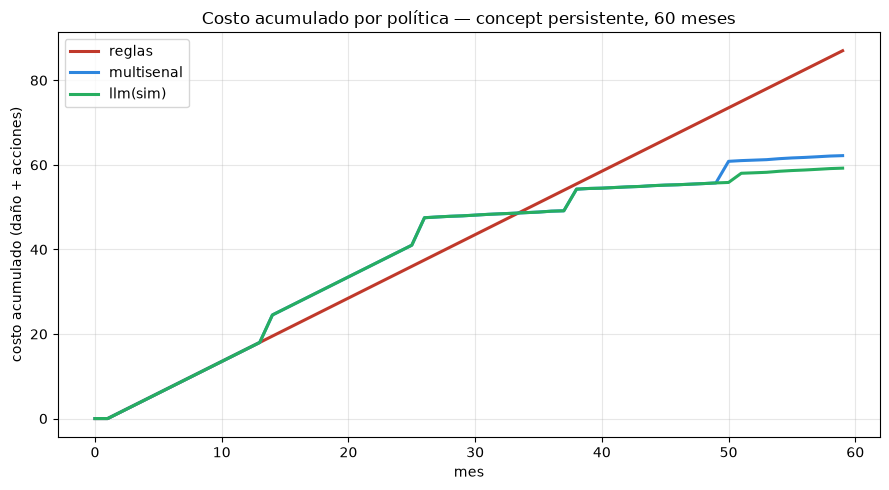

In [5]:
colores = {"reglas": "#C0392B", "multisenal": "#2E86DE", "llm(sim)": "#27AE60"}
fig, ax = plt.subplots(figsize=(9, 5))
for nombre, df in tray.items():
    ax.plot(df["periodo"], df["costo_acum"], label=nombre, linewidth=2.2, color=colores.get(nombre))
ax.set_xlabel("mes"); ax.set_ylabel("costo acumulado (daño + acciones)")
ax.set_title(f"Costo acumulado por política — concept persistente, {N} meses")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Chequeo 5 — el horizonte importa

Con retardo de 12 meses, la intervención inteligente solo **paga** con horizonte largo: con pocos meses conviene no hacer nada (reglas gana); con muchos, las políticas listas ganan. Tarda ~2 min.

In [6]:
filas = []
for n in [30, 48, 60]:
    cfg_n = ConfigSimulacion(n_periodos=n, tam_lote=2000, semilla=13579)
    plan_n = agregar_episodio(plan_sano(n), "concept_drift", inicio=2, fin=n, intensidad=1.0, forma="escalon")
    _, res = comparar_con_efecto(politicas(), pool, cfg_n, plan_n, modelo, referencia, ventana=10, lag=1)
    for pol in res.index:
        filas.append({"horizonte(meses)": n, "politica": pol, "costo_total": res.loc[pol, "costo_total"]})

tabla = pd.DataFrame(filas).pivot(index="politica", columns="horizonte(meses)", values="costo_total")
tabla

horizonte(meses),30,48,60
politica,,,
llm(sim),47.95,55.44,59.23
multisenal,47.95,55.44,62.19
reglas,42.00,69.00,87.00
